In [13]:
import pandas as pd
from pathlib import Path
from collections import defaultdict
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [14]:
df = pd.read_csv('../input/input_datasets/excluded_datasets_list.csv')
df.head()

,region,data_group,dataset,exclusion_type,inclusion_possible
0,alaska,demdiff_and_glaciological,UZH_GlaciolSineWave,annual,yes
1,alaska,demdiff_and_glaciological,WGMS-mean_ba,annual,yes
2,alaska,gravimetry,Jacob_2012_dmdt,annual,yes
3,antarctic_and_subantarctic,altimetry,Gardner2013_icesat,annual,no
4,antarctic_and_subantarctic,altimetry,Khan,annual,yes


In [15]:
# Number of total excluded datasets
len(df)

142

In [16]:
dataset_to_group = {} 
counts = defaultdict(int)

for f in Path('.').rglob('*.csv'):
    dataset = f.stem
    data_group = f.parent.name
    if dataset not in dataset_to_group:
        dataset_to_group[dataset] = data_group
    counts[dataset] += 1

# Build DataFrame with both
result = pd.DataFrame([
    (ds, dataset_to_group[ds], n) 
    for ds, n in sorted(counts.items(), key=lambda x: -x[1])
], columns=['dataset', 'data_group', 'n_regions'])

print(result.head(25))

Empty DataFrame
Columns: [dataset, data_group, n_regions]
Index: []


In [17]:
# Dataset count per source and which method they belong to
agg = df.groupby('dataset').agg(
    data_groups=('data_group', lambda x: ', '.join(sorted(x.unique()))),
    count=('region', 'count')
).sort_values('count', ascending=False)
print(agg.to_string()) # Most important/commonly used datasets: Jacob_2012_dmdt, Wouters, WGMS-mean_ba, UZH_GlaciolSineWeve, Sasgen_AWIarc_RL01_2, Harig_Group, Gardner2013_icesat, Treichler_ICESat

print(f"\nNumber of datasets (unique): {len(agg)}")

                                    data_groups  count
dataset                                               
Jacob_2012_dmdt                      gravimetry     27
Wouters                              gravimetry     20
WGMS-mean_ba          demdiff_and_glaciological     19
UZH_GlaciolSineWave   demdiff_and_glaciological     18
Sasgen_AWIarc_RL01_2                 gravimetry     18
Harig_Group                          gravimetry      8
Gardner2013_icesat                    altimetry      6
Treichler_ICESat                      altimetry      6
Tepes                                 altimetry      5
Khan                                  altimetry      4
Treichler_snowfall                    altimetry      3
Ke                                    altimetry      3
Bolch_2013                            altimetry      1
Menounos_WNA_glac     demdiff_and_glaciological      1
Menounos_WNA_alt1                     altimetry      1
Foresta                               altimetry      1
Menounos_W

In [18]:
agg = df.drop_duplicates(subset=['region', 'data_group', 'dataset']).groupby('dataset').agg(
    data_groups=('data_group', lambda x: ', '.join(sorted(x.unique()))),
    count=('region', 'count')
).sort_values('count', ascending=False)

print(agg.to_string()) # datasets annual/trend combined

                                    data_groups  count
dataset                                               
WGMS-mean_ba          demdiff_and_glaciological     19
UZH_GlaciolSineWave   demdiff_and_glaciological     18
Jacob_2012_dmdt                      gravimetry     17
Wouters                              gravimetry     10
Sasgen_AWIarc_RL01_2                 gravimetry      9
Gardner2013_icesat                    altimetry      6
Tepes                                 altimetry      5
Khan                                  altimetry      4
Harig_Group                          gravimetry      4
Treichler_snowfall                    altimetry      3
Treichler_ICESat                      altimetry      3
Ke                                    altimetry      3
Bolch_2013                            altimetry      1
Menounos_WNA_glac     demdiff_and_glaciological      1
Menounos_WNA_alt1                     altimetry      1
Foresta                               altimetry      1
Menounos_W

In [19]:
# Dataset count per source and which method they belong to (only includable)
includable = df[df['inclusion_possible'] == 'yes']
agg = includable.groupby('dataset').agg(
    data_groups=('data_group', lambda x: ', '.join(sorted(x.unique()))),
    count=('region', 'count')
).sort_values('count', ascending=False)
print(agg.to_string()) # the most commonly used datasets are not affected by inclusion

                                    data_groups  count
dataset                                               
Jacob_2012_dmdt                      gravimetry     27
Wouters                              gravimetry     20
WGMS-mean_ba          demdiff_and_glaciological     19
UZH_GlaciolSineWave   demdiff_and_glaciological     18
Sasgen_AWIarc_RL01_2                 gravimetry     18
Harig_Group                          gravimetry      8
Tepes                                 altimetry      5
Gardner2013_icesat                    altimetry      4
Treichler_ICESat                      altimetry      3
Ke                                    altimetry      3
Khan                                  altimetry      2
Menounos_WNA_alt1                     altimetry      1
Foresta                               altimetry      1
Menounos_WNA_glac     demdiff_and_glaciological      1
Menounos_WNA_is2gedi                  altimetry      1


In [20]:
# Dataset count per source and which method they belong to (only non-includable)
non_includable = df[df['inclusion_possible'] == 'no']
agg = non_includable.groupby('dataset').agg(
    data_groups=('data_group', lambda x: ', '.join(sorted(x.unique()))),
    count=('region', 'count')
).sort_values('count', ascending=False)
print(agg.to_string()) # so it is mostly altimetry datasets which we cannot use

                   data_groups  count
dataset                              
Treichler_snowfall   altimetry      3
Treichler_ICESat     altimetry      3
Khan                 altimetry      2
Gardner2013_icesat   altimetry      2
Bolch_2013           altimetry      1


In [21]:
# exclusion_type vs inclusion_possible
print(pd.crosstab(df['exclusion_type'], df['inclusion_possible'], margins=False)) # only annual datasets cause problems with inclusion -> what even are annual and trend datasets, what is the difference?

inclusion_possible  no  yes
exclusion_type             
annual              11   95
trend                0   36


In [22]:
dataset_meta = pd.read_csv('../input/input_datasets/dataset_inclusion.csv', encoding='latin1')
dataset_meta.head()

,Research team,Observation method,Sensor / Product,Alaska,Western Canada & USA,Arctic Canada North,Arctic Canada South,Greenland Periphery,Iceland,Svalbard,...,North Asia,Central Europe,Caucasus,Central Asia,South Asia West,South Asia East,Low Latitudes,Southern Andes,New Zealand,Antarctic & Subantarctic
0,Abdullahi et al.,DEM differencing,TanDEM-X,NaN,NaN,NaN,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Andreassen et al.,DEM differencing,Airborne LiDAR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Bolch et al.,Altimetry,ICESat,NaN,NaN,NaN,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Box et al.,Hybrid,In situ | GRACE,1.0,NaN,1.0,1.0,NaN,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Braun et al.,DEM differencing,TanDEM-X,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN


In [23]:
# Visualizations using dataset_inclusion.csv (wide matrix format)

# First, transform wide to long format for easier analysis
region_cols = [col for col in dataset_meta.columns if col not in ['Research team', 'Observation method', 'Sensor / Product']]
long_data = dataset_meta.melt(
    id_vars=['Research team', 'Observation method', 'Sensor / Product'],
    value_vars=region_cols,
    var_name='region',
    value_name='inclusion'
)

# Clean up: drop NaN (not applicable) and map values
long_data = long_data.dropna(subset=['inclusion'])
long_data['inclusion_status'] = long_data['inclusion'].map({1.0: 'Included', -1.0: 'Excluded'})

# Create a dataset identifier
long_data['dataset'] = long_data['Research team'] + " (" + long_data['Observation method'] + ")"

print(f"Total dataset-region combinations: {len(long_data)}")
print(f"Unique datasets: {long_data['dataset'].nunique()}")
print(f"Regions: {long_data['region'].nunique()}")
print("\nInclusion status distribution:")
print(long_data['inclusion_status'].value_counts())

Total dataset-region combinations: 233
Unique datasets: 39
Regions: 19

Inclusion status distribution:
inclusion_status
Included    192
Excluded     41
Name: count, dtype: int64


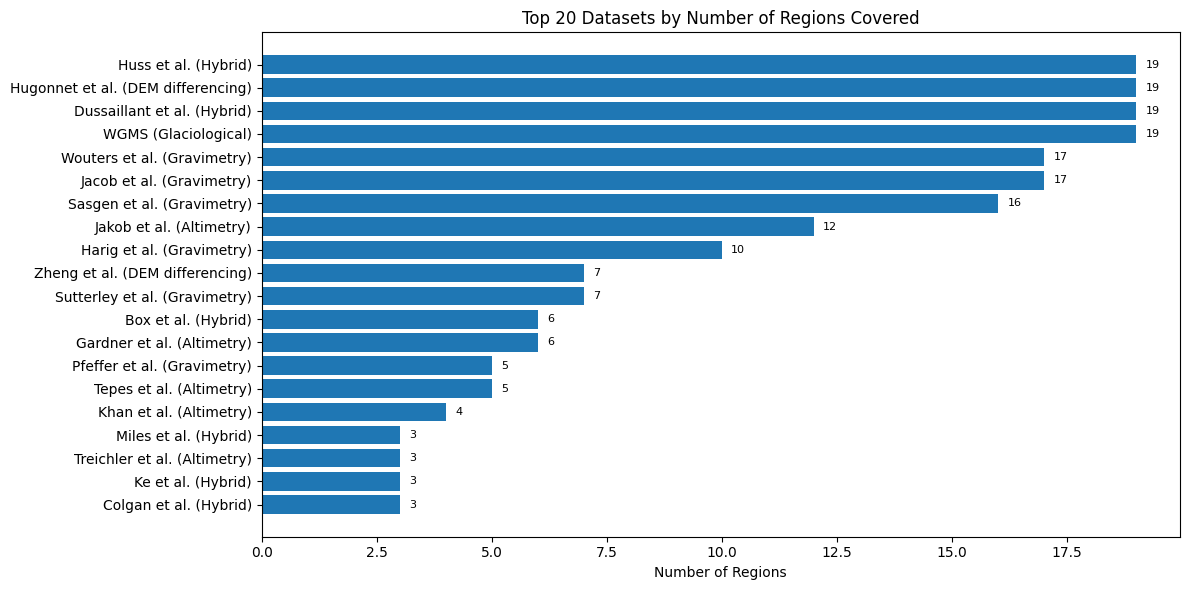

In [24]:
# 1. Bar chart: Number of regions per dataset (top 20)
regions_per_dataset = long_data.groupby('dataset')['region'].nunique().sort_values(ascending=False).head(20)
plt.figure(figsize=(12, 6))
bars = plt.barh(range(len(regions_per_dataset)), regions_per_dataset.values)
plt.yticks(range(len(regions_per_dataset)), [str(x)[:50] for x in regions_per_dataset.index])
plt.xlabel('Number of Regions')
plt.title('Top 20 Datasets by Number of Regions Covered')
plt.gca().invert_yaxis()
for i, (bar, val) in enumerate(zip(bars, regions_per_dataset.values)):
    plt.text(val + 0.2, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=8)
plt.tight_layout()
plt.show()

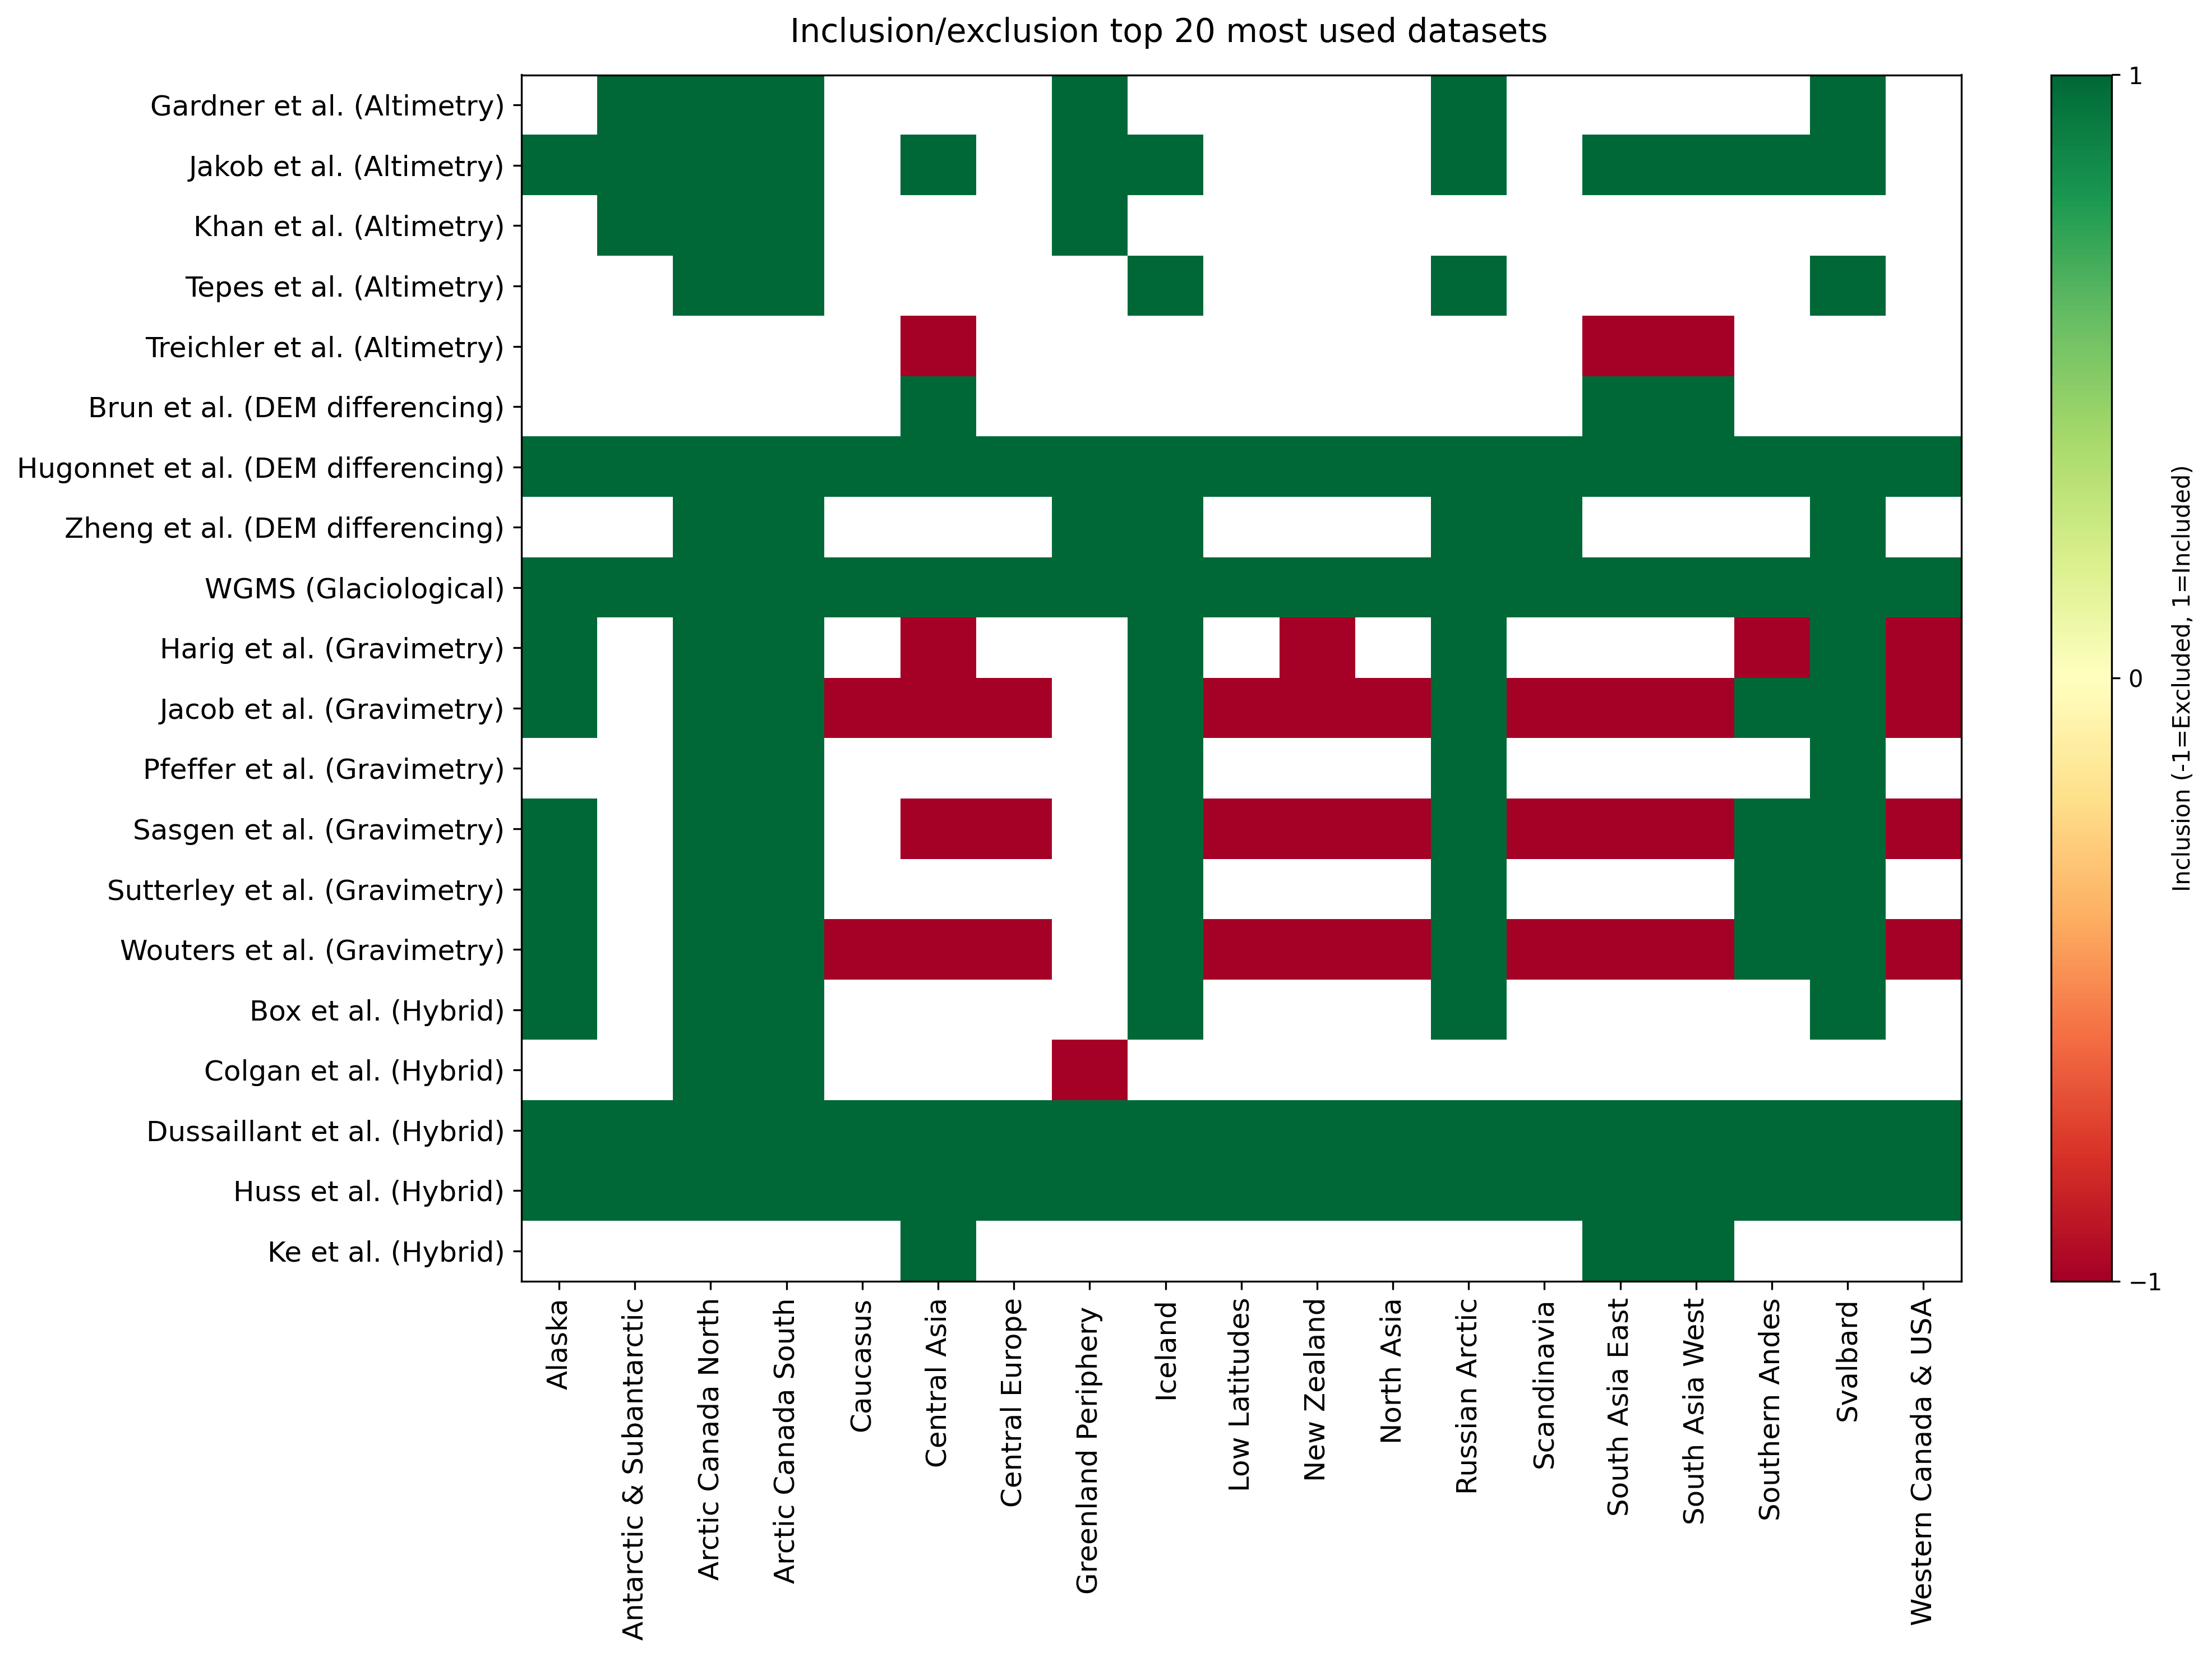

In [25]:
# 3. Heatmap: Inclusion matrix (datasets x regions) - sorted by observation method
top_datasets = long_data['dataset'].value_counts().head(20).index
heatmap_data = long_data[long_data['dataset'].isin(top_datasets)].pivot_table(
    index='dataset',
    columns='region',
    values='inclusion',
    aggfunc='first'
)

# # Region mappings
# regions_bar = {
#     "1_alaska": "Alaska",
#     "2_western_canada_us": "W. Canada & US",
#     "3_arctic_canada_north": "Arctic Canada N.",
#     "4_arctic_canada_south": "Arctic Canada S.",
#     "5_greenland_periphery": "Greenland Per.",
#     "6_iceland": "Iceland",
#     "7_svalbard": "Svalbard",
#     "8_scandinavia": "Scandinavia",
#     "9_russian_arctic": "Russian Arctic",
#     "10_north_asia": "North Asia",
#     "11_central_europe": "Central Europe",
#     "12_caucasus_middle_east": "Caucasus & M.E.",
#     "13_central_asia": "Central Asia",
#     "14_south_asia_west": "South Asia W.",
#     "15_south_asia_east": "South Asia E.",
#     "16_low_latitudes": "Low Latitudes",
#     "17_southern_andes": "Southern Andes",
#     "18_new_zealand": "New Zealand",
#     "19_antarctic_and_subantarctic": "Antarctic & Sub.",
# }

# # 1) Rename region columns to your preferred display names
# heatmap_data = heatmap_data.rename(columns=regions_bar)

# # 2) Force the exact column order you want
# region_order = list(regions_bar.values())
# heatmap_data = heatmap_data.reindex(columns=region_order)

# Sort by observation method (extracted from dataset name) then by dataset name
# Dataset format: "Research team (Observation method)"
def get_method(dataset_name):
    # Extract method from parentheses
    if '(' in dataset_name and ')' in dataset_name:
        return dataset_name.split('(')[-1].rstrip(')').strip()
    return ''

sorted_index = sorted(heatmap_data.index, key=lambda x: (get_method(x), x))
heatmap_data_sorted = heatmap_data.reindex(sorted_index)

plt.figure(figsize=(14, 10), dpi=300)
# Map: 1.0 = green (included), -1.0 = red (excluded)
cmap = plt.cm.RdYlGn  # Red for -1, Yellow for 0, Green for 1
im = plt.imshow(heatmap_data_sorted, cmap=cmap, aspect='auto', vmin=-1, vmax=1)
plt.colorbar(im, ticks=[-1, 0, 1], label='Inclusion (-1=Excluded, 1=Included)')
plt.suptitle("Inclusion/exclusion top 20 most used datasets", fontsize=14)
plt.xticks(range(len(heatmap_data_sorted.columns)), heatmap_data_sorted.columns, rotation=90, fontsize=12)
plt.yticks(range(len(heatmap_data_sorted.index)), heatmap_data_sorted.index, fontsize=12)
plt.tight_layout()
plt.show()

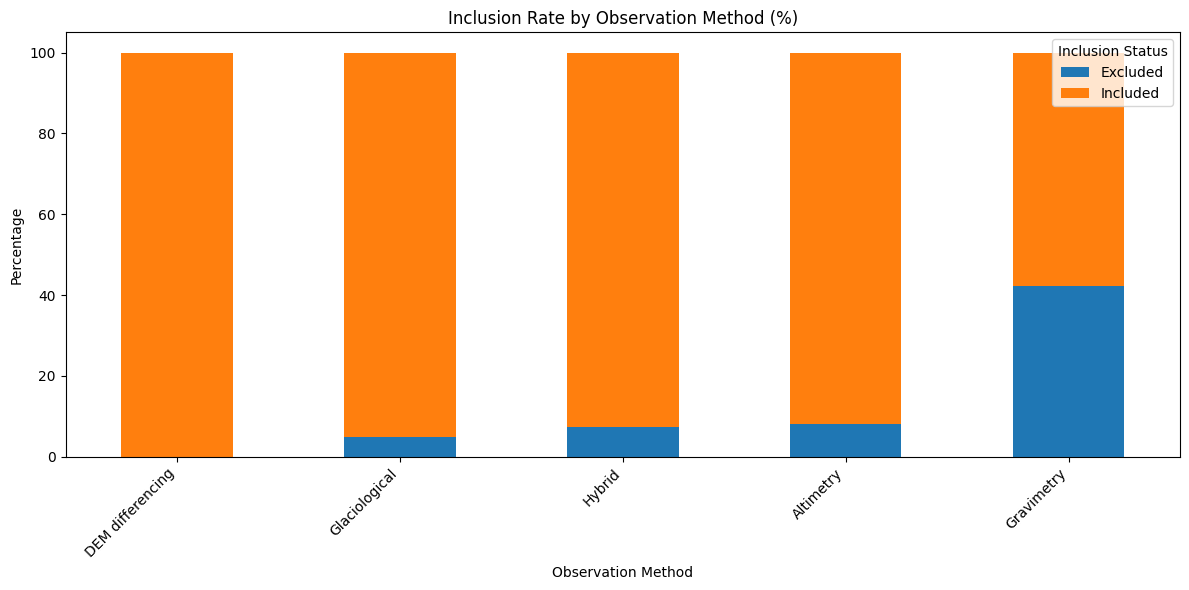

In [26]:
# 4. Stacked bar: Inclusion rate by observation method
obs_method_stats = pd.crosstab(long_data['Observation method'], long_data['inclusion_status'], normalize='index') * 100
obs_method_stats = obs_method_stats.sort_values('Included', ascending=False)
obs_method_stats.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Inclusion Rate by Observation Method (%)')
plt.xlabel('Observation Method')
plt.ylabel('Percentage')
plt.legend(title='Inclusion Status')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()